# Image Colorization

Import libraries:

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from skimage.color import rgb2lab, rgb2gray, lab2rgb
from PIL import Image
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Download dataset:

In [2]:
import kagglehub

path = kagglehub.dataset_download("theblackmamba31/landscape-image-colorization")
color_path = path + "/landscape Images/color"  # path to colored images

100%|██████████| 192M/192M [00:01<00:00, 173MB/s]

Extracting files...


In [3]:
class ColorizationNet(nn.Module):
    """
    CNN for image colorization.
    Encoder: first 6 layers of ResNet34 (adapted for 1-channel grayscale input).
    Decoder: series of convolutions + upsampling to predict AB channels in LAB color space.
    """
    def __init__(self):
        super(ColorizationNet, self).__init__()
        resnet = models.resnet34(weights=None)
        # Adapt first convolution for grayscale (1 channel)
        resnet.conv1.weight = nn.Parameter(resnet.conv1.weight.sum(dim=1, keepdim=True))

        self.encoder = nn.Sequential(*list(resnet.children())[:6])

        self.decoder = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 2, kernel_size=3, stride=1, padding=1),
            nn.Upsample(scale_factor=2)
        )

    def forward(self, x):
        """Forward pass: grayscale -> predicted AB channels."""
        x = self.encoder(x)
        x = self.decoder(x)
        return x

class ColorizeDataset(Dataset):
    """
    Dataset for colorization task.

    Args:
        root_dir (str): Path to folder with color images.
        transform (callable, optional): Transform to be applied on image.

    Returns:
        tuple: (grayscale tensor, ab channels tensor)
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir)
                           if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.image_files.sort()

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        img = np.array(img)

        # Convert RGB to LAB color space
        lab = rgb2lab(img)
        lab = (lab + 128) / 255.0  # normalize to [0, 1]
        ab = lab[:, :, 1:].transpose(2, 0, 1).astype(np.float32)
        gray = rgb2gray(img).astype(np.float32)

        return torch.from_numpy(gray).unsqueeze(0), torch.from_numpy(ab)

transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224)
])

dataset = ColorizeDataset(color_path, transform=transform)

# Train / val split (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

Train model:

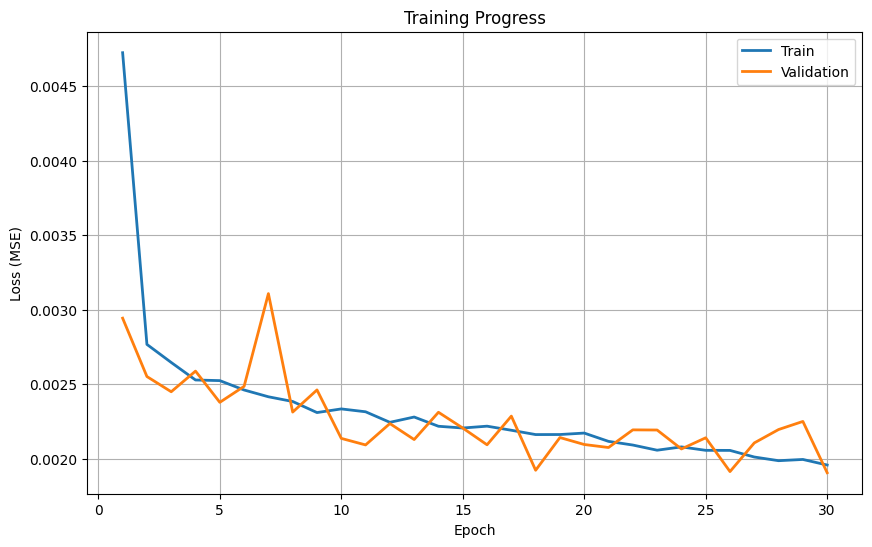

Training completed in 29m 38s
Final Train Loss: 0.0020
Final Val Loss:   0.0019


In [4]:
model = ColorizationNet().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 30

# History for plotting
history = {"train_loss": [], "val_loss": []}

start_time = time.time()

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    for gray, ab in train_loader:
        gray = gray.to(device)
        ab = ab.to(device)

        optimizer.zero_grad()
        output = model(gray)
        loss = criterion(output, ab)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for gray, ab in val_loader:
            gray = gray.to(device)
            ab = ab.to(device)
            output = model(gray)
            val_loss += criterion(output, ab).item()

    avg_val_loss = val_loss / len(val_loader)

    # Save to history
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    # Plot training process
    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epoch+2), history["train_loss"], label="Train", linewidth=2)
    plt.plot(range(1, epoch+2), history["val_loss"], label="Validation", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title("Training Progress")
    plt.legend()
    plt.grid(True)
    plt.show()

total_time = int(time.time() - start_time)
print(f"Training completed in {total_time//60}m {total_time%60}s")
print(f"Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Val Loss:   {history['val_loss'][-1]:.4f}")

# Save model
os.makedirs("models", exist_ok=True)
torch.save(model, "models/model.pth")